# Event Impact Modeling
**Ethiopia Financial Inclusion Forecasting — Selam Analytics**

Objective: translate `impact_link` records into a model that predicts how Access/Usage
indicators change in response to events (policies, product launches, infrastructure), test
that model against Ethiopia's own history, and refine it based on what the test reveals.

Builds on Task 1 (`src/data_loader.py`, `src/enrichment.py`) and Task 2's findings — in
particular the registered-vs-active gap and the observation that Ethiopia's mobile money
adoption pace looks much slower than comparable markets. Modeling logic lives in
`src/impact_model.py`; this notebook applies and validates it.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")
FIG_DIR = Path.cwd().parent / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

from src.data_loader import (
    load_unified_data, load_reference_codes, get_observations, get_events,
    get_impact_links, link_events_to_impacts, review_impact_links,
)
from src.enrichment import add_record, append_log_entry
from src.impact_model import (
    MAGNITUDE_TO_PP, get_effects_for_indicator, ramp, predicted_change,
    validate_indicator, build_association_matrix,
)

COLLECTED_BY = "Meron Sisay"
COLLECTION_DATE = "2026-07-18"

df = load_unified_data()
reference = load_reference_codes()
print(f"Loaded {len(df)} records: {df['record_type'].value_counts().to_dict()}")


Loaded 73 records: {'observation': 42, 'impact_link': 17, 'event': 11, 'target': 3}


## 1. Understand the Impact Data

Load `impact_link` records and join them back to their parent `event` via `parent_id`,
producing a single summary: which events affect which indicators, in what direction, by
roughly how much, and how confident/well-evidenced each claim is.


In [2]:
links = review_impact_links(df)
print(f"{len(links)} impact_link records, covering {links['related_indicator_impact'].nunique()} distinct indicators")
links.sort_values(["indicator_event", "related_indicator_impact"])


17 impact_link records, covering 11 distinct indicators


,record_id_impact,indicator_event,category_event,pillar_impact,related_indicator_impact,impact_direction_impact,impact_magnitude_impact,lag_months_impact,evidence_basis_impact,confidence_impact
12,IMP_0013,EthioPay Instant Payment System Launch,infrastructure,USAGE,USG_P2P_COUNT,increase,medium,6.0,literature,medium
7,IMP_0008,Fayda Digital ID Program Rollout,infrastructure,ACCESS,ACC_OWNERSHIP,increase,medium,24.0,literature,medium
8,IMP_0009,Fayda Digital ID Program Rollout,infrastructure,GENDER,GEN_GAP_ACC,decrease,medium,24.0,literature,medium
9,IMP_0010,Foreign Exchange Liberalization,policy,AFFORDABILITY,AFF_DATA_INCOME,increase,high,3.0,empirical,high
10,IMP_0011,M-Pesa EthSwitch Integration,partnership,USAGE,USG_MPESA_ACTIVE,increase,medium,3.0,literature,medium
11,IMP_0012,M-Pesa EthSwitch Integration,partnership,USAGE,USG_P2P_COUNT,increase,medium,3.0,literature,medium
6,IMP_0007,M-Pesa Ethiopia Launch,product_launch,ACCESS,ACC_MM_ACCOUNT,increase,medium,6.0,theoretical,medium
5,IMP_0006,M-Pesa Ethiopia Launch,product_launch,USAGE,USG_MPESA_USERS,increase,high,3.0,empirical,high
16,IMP_0017,NBE Revised Payment Instrument Issuer Directiv...,regulation,ACCESS,ACC_MM_ACCOUNT,increase,low,12.0,theoretical,low
15,IMP_0016,NBE Revised Payment Instrument Issuer Directiv...,regulation,USAGE,USG_P2P_VALUE,increase,medium,6.0,theoretical,medium


In [3]:
# Full join, including comparable_country -- needed for Section 3
full_join = link_events_to_impacts(df)
summary_cols = ["indicator_event", "category_event", "related_indicator_impact",
                 "impact_direction_impact", "impact_magnitude_impact", "lag_months_impact",
                 "evidence_basis_impact", "comparable_country_impact", "confidence_impact"]
event_indicator_summary = full_join[summary_cols].rename(columns=lambda c: c.replace("_impact", "").replace("_event", "_evt"))
event_indicator_summary.sort_values(["indicator_evt", "related_indicator"])


,indicator_evt,category_evt,related_indicator,impact_direction,impact_magnitude,lag_months,evidence_basis,comparable_country,confidence
12,EthioPay Instant Payment System Launch,infrastructure,USG_P2P_COUNT,increase,medium,6.0,literature,India,medium
7,Fayda Digital ID Program Rollout,infrastructure,ACC_OWNERSHIP,increase,medium,24.0,literature,India,medium
8,Fayda Digital ID Program Rollout,infrastructure,GEN_GAP_ACC,decrease,medium,24.0,literature,India,medium
9,Foreign Exchange Liberalization,policy,AFF_DATA_INCOME,increase,high,3.0,empirical,NaN,high
10,M-Pesa EthSwitch Integration,partnership,USG_MPESA_ACTIVE,increase,medium,3.0,literature,Tanzania,medium
11,M-Pesa EthSwitch Integration,partnership,USG_P2P_COUNT,increase,medium,3.0,literature,Tanzania,medium
6,M-Pesa Ethiopia Launch,product_launch,ACC_MM_ACCOUNT,increase,medium,6.0,theoretical,NaN,medium
5,M-Pesa Ethiopia Launch,product_launch,USG_MPESA_USERS,increase,high,3.0,empirical,NaN,high
16,NBE Revised Payment Instrument Issuer Directiv...,regulation,ACC_MM_ACCOUNT,increase,low,12.0,theoretical,NaN,low
15,NBE Revised Payment Instrument Issuer Directiv...,regulation,USG_P2P_VALUE,increase,medium,6.0,theoretical,NaN,medium


**Observation**: 17 impact_links cover 11 events, but coverage is uneven -- Telebirr (the
first and largest product launch) has 4 links, while several smaller events (Foreign Exchange
Liberalization, Safaricom's price increase) have only 1. This mirrors the sparse-coverage
pattern already flagged in Task 2.


## 2. Build the Event-Indicator Effect Model

Three design questions from the brief, answered explicitly (full reasoning in the
Methodology section at the end):

**How is an event's effect represented over time?** As a **linear ramp**: 0 at the event
date, rising steadily to its full estimated magnitude at `event_date + lag_months`, then
holding constant (no decay, no overshoot). This is a simplifying assumption, not a fitted
curve — there isn't enough Ethiopia data to fit a real diffusion curve (Task 2's finding:
most indicators have 1-2 points total).

**Do effects happen immediately or build gradually?** Gradually — the ramp *is* the
gradual-build assumption. `lag_months` controls how fast.

**How are effects from multiple events combined?** **Additively.** Each event contributes
independently; effects on the same indicator simply sum. This ignores possible
interaction/saturation effects (e.g. Telebirr and M-Pesa competing for the same limited pool
of not-yet-banked adults) — flagged as a limitation, not hidden.

**Turning categorical magnitude into a number**: `low/medium/high` → `2/5/10` percentage
points. This mapping is an explicit assumption, calibrated (not just asserted) in Section 5.


In [4]:
print("Magnitude -> percentage-point mapping (initial, before calibration):")
for k, v in MAGNITUDE_TO_PP.items():
    print(f"  {k:8s} -> {v:+.1f}pp")


Magnitude -> percentage-point mapping (initial, before calibration):
  low      -> +2.0pp
  medium   -> +5.0pp
  high     -> +10.0pp


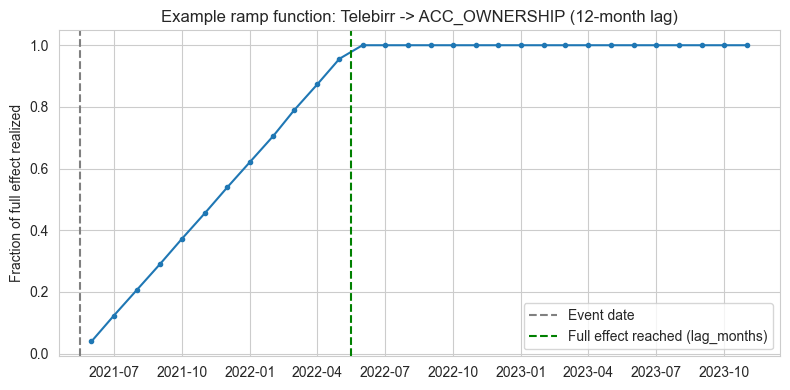

In [5]:
# Demonstrate the ramp function for Telebirr's existing ACC_OWNERSHIP link (IMP_0001:
# high magnitude, 12-month lag) -- shows what "gradual build, then flat" looks like.
telebirr_launch = pd.Timestamp("2021-05-17")
months = pd.date_range(telebirr_launch, telebirr_launch + pd.DateOffset(months=30), freq="MS")
ramp_values = [ramp(t, telebirr_launch, lag_months=12) for t in months]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(months, ramp_values, marker="o", markersize=3)
ax.axvline(telebirr_launch, color="gray", linestyle="--", label="Event date")
ax.axvline(telebirr_launch + pd.DateOffset(months=12), color="green", linestyle="--", label="Full effect reached (lag_months)")
ax.set_title("Example ramp function: Telebirr -> ACC_OWNERSHIP (12-month lag)")
ax.set_ylabel("Fraction of full effect realized")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "impact_ramp_example.png", dpi=150)
plt.show()


## 3. Review Comparable Country Evidence

Where Ethiopia's own before/after data is too sparse to estimate an effect directly (true for
most Access-side links, per Task 2), the starter dataset already cites comparable-country
evidence via the `comparable_country` field. Surfacing those explicitly:


In [6]:
comparable = event_indicator_summary[event_indicator_summary["comparable_country"].notna()]
print(f"{len(comparable)} of {len(event_indicator_summary)} impact_links rely on comparable-country evidence:")
comparable[["indicator_evt", "related_indicator", "comparable_country", "impact_magnitude", "lag_months"]]


7 of 17 impact_links rely on comparable-country evidence:


,indicator_evt,related_indicator,comparable_country,impact_magnitude,lag_months
0,Telebirr Launch,ACC_OWNERSHIP,Kenya,high,12.0
4,Safaricom Ethiopia Commercial Launch,AFF_DATA_INCOME,Rwanda,medium,12.0
7,Fayda Digital ID Program Rollout,ACC_OWNERSHIP,India,medium,24.0
8,Fayda Digital ID Program Rollout,GEN_GAP_ACC,India,medium,24.0
10,M-Pesa EthSwitch Integration,USG_MPESA_ACTIVE,Tanzania,medium,3.0
11,M-Pesa EthSwitch Integration,USG_P2P_COUNT,Tanzania,medium,3.0
12,EthioPay Instant Payment System Launch,USG_P2P_COUNT,India,medium,6.0


**New comparable-country evidence gathered for this task**: there is currently no
`impact_link` connecting Telebirr's launch to `ACC_MM_ACCOUNT` (mobile money account
ownership) — a real gap, given Telebirr is literally the product that created this market in
Ethiopia. Kenya's M-Pesa (the most-studied comparable case) is well documented:

> "M‐PESA has grown rapidly, reaching approximately 65 percent of Kenyan households by the
> end of 2009" — roughly 2.5-3 years after its March 2007 launch.
> — Jack & Suri, "Mobile Money: The Economics of M-PESA", NBER Working Paper
https://www.nber.org/system/files/working_papers/w16721/w16721.pdf

Adding this as a new `impact_link`, using Kenya as the comparable-country basis — deliberately
using an *aggressive, naive* estimate first, so Section 5's validation can show explicitly how
far off it is from what actually happened in Ethiopia, rather than quietly calibrating it to
fit before showing any work.


In [7]:
df, added = add_record(df, {
    "record_type": "impact_link", "parent_id": "EVT_0001", "pillar": "ACCESS",
    "related_indicator": "ACC_MM_ACCOUNT", "relationship_type": "direct",
    "impact_direction": "increase", "impact_magnitude": "high", "lag_months": 24,
    "evidence_basis": "literature", "comparable_country": "Kenya", "confidence": "low",
    "source_name": "Jack & Suri (NBER)",
    "source_url": "https://www.nber.org/system/files/working_papers/w16721/w16721.pdf",
    "original_text": "M-PESA has grown rapidly, reaching approximately 65 percent of Kenyan households by the end of 2009.",
    "notes": ("Naive initial estimate before calibration -- Kenya's M-Pesa reached ~65% household "
              "adoption within ~2.5-3 years of launch. Confidence set to 'low' because this is a "
              "single comparable-country data point applied to a structurally different market "
              "(see Section 5 validation)."),
})
if added:
    append_log_entry(
        record_id=df.iloc[-1]["record_id"], record_type="impact_link",
        description="Telebirr launch -> ACC_MM_ACCOUNT (new, comparable-country based)",
        source_url="https://www.nber.org/system/files/working_papers/w16721/w16721.pdf",
        original_text="M-PESA has grown rapidly, reaching approximately 65 percent of Kenyan households by the end of 2009.",
        confidence="low", collected_by=COLLECTED_BY, collection_date=COLLECTION_DATE,
        notes=("Fills a real gap -- no prior link connected Telebirr, the product that created "
               "Ethiopia's mobile money market, to ACC_MM_ACCOUNT. Deliberately left as a naive, "
               "un-calibrated estimate here; Section 5/6 test and refine it against actual data."),
    )
    print(f"Added {df.iloc[-1]['record_id']}: Telebirr -> ACC_MM_ACCOUNT")
else:
    print("Skipped (already present): Telebirr -> ACC_MM_ACCOUNT")


Added IMP_0018: Telebirr -> ACC_MM_ACCOUNT


## 4. Create the Association Matrix

Rows = events, columns = key indicators, values = estimated signed effect in percentage
points (using the initial, un-calibrated magnitude mapping). This is the static "which event
affects which indicator, by how much" summary.


In [8]:
key_indicators = ["ACC_OWNERSHIP", "ACC_MM_ACCOUNT", "ACC_AGENT_COUNT", "ACC_4G_COV",
                   "USG_DIGITAL_PAYMENT", "USG_P2P_COUNT", "USG_P2P_VALUE", "USG_TELEBIRR_USERS",
                   "USG_MPESA_USERS", "USG_MPESA_ACTIVE", "GEN_GAP_ACC", "AFF_DATA_INCOME"]

matrix = build_association_matrix(df, key_indicators, dampening=1.0)
matrix.to_csv(PROCESSED_DIR / "event_indicator_association_matrix.csv")
matrix


,ACC_OWNERSHIP,ACC_MM_ACCOUNT,ACC_AGENT_COUNT,ACC_4G_COV,USG_DIGITAL_PAYMENT,USG_P2P_COUNT,USG_P2P_VALUE,USG_TELEBIRR_USERS,USG_MPESA_USERS,USG_MPESA_ACTIVE,GEN_GAP_ACC,AFF_DATA_INCOME
indicator,,,,,,,,,,,,
Telebirr Launch,10.0,10.0,10.0,NaN,NaN,10.0,NaN,10.0,NaN,NaN,NaN,NaN
Safaricom Ethiopia Commercial Launch,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-5.0
M-Pesa Ethiopia Launch,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN
Fayda Digital ID Program Rollout,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-5.0,NaN
Foreign Exchange Liberalization,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0
P2P Transaction Count Surpasses ATM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
M-Pesa EthSwitch Integration,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,5.0,NaN,NaN
EthioPay Instant Payment System Launch,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN
NFIS-II Strategy Launch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


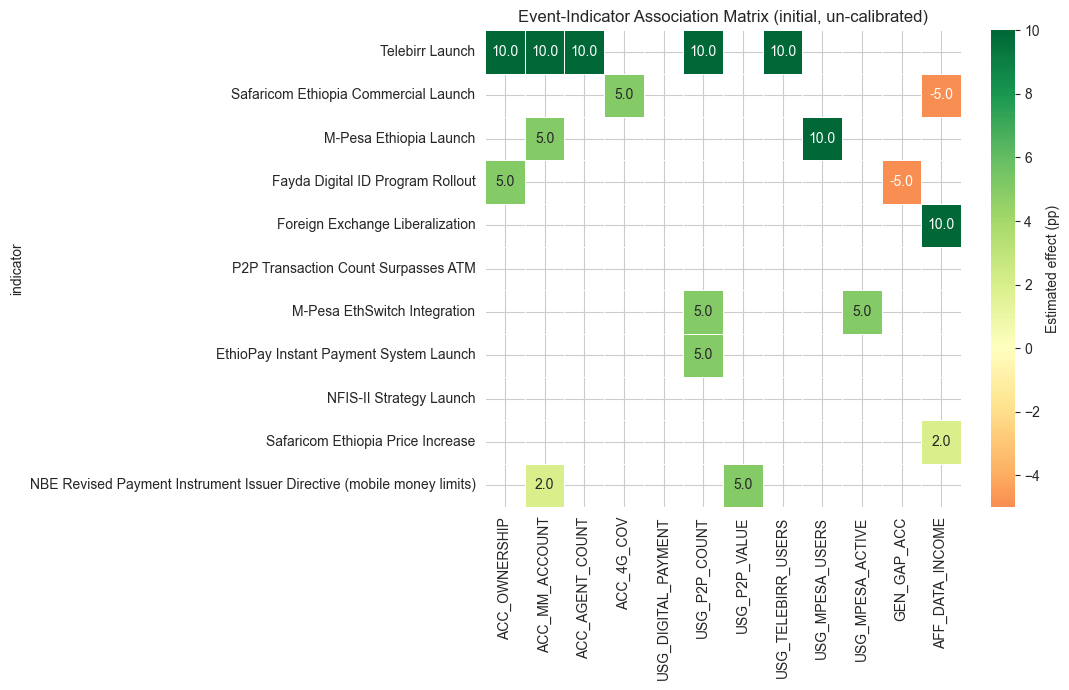

In [9]:
fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(matrix.astype(float), cmap="RdYlGn", center=0, annot=True, fmt=".1f",
            linewidths=0.5, linecolor="white", cbar_kws={"label": "Estimated effect (pp)"}, ax=ax)
ax.set_title("Event-Indicator Association Matrix (initial, un-calibrated)")
plt.tight_layout()
plt.savefig(FIG_DIR / "association_matrix_initial.png", dpi=150)
plt.show()


## 5. Test the Model Against Historical Data

The brief's own test case: Telebirr launched May 2021; `ACC_MM_ACCOUNT` went from 4.7%
(2021-12-31) to 9.45% (2024-11-29). Does the model's predicted change over that window match
what actually happened?


In [10]:
t0 = pd.Timestamp("2021-12-31")
t1 = pd.Timestamp("2024-11-29")
actual_t0, actual_t1 = 4.7, 9.45

result_naive = validate_indicator(df, "ACC_MM_ACCOUNT", t0, t1, actual_t0, actual_t1, dampening=1.0)
for k, v in result_naive.items():
    print(f"{k:16s}: {v}")


indicator_code  : ACC_MM_ACCOUNT
t0              : 2021-12-31 00:00:00
t1              : 2024-11-29 00:00:00
actual_t0       : 4.7
actual_t1       : 9.45
actual_delta    : 4.749999999999999
predicted_delta : 13.891699518177836
predicted_t1    : 18.591699518177837
error_pp        : 9.141699518177838
n_events        : 3


**Result**: the naive, comparable-country-calibrated model badly overshoots — predicting far
more growth than Ethiopia actually saw. This is a real, informative finding, not a modeling
failure to hide: it quantifies exactly how much slower Ethiopia's adoption has been than
Kenya's, and *why* is worth spelling out using Task 2's own findings:

1. **Kenya's banked population was tiny pre-M-Pesa** (few alternatives existed), so M-Pesa
   *was* financial inclusion for most adopters. **Ethiopia's banked population was already
   substantial pre-Telebirr**, so — per Task 2's hypothesis — many new mobile accounts likely
   belong to people who were already banked, muting the incremental effect on account-level
   metrics.
2. **Agent network growth stalled** (200k→216k, 2022-2024, Task 2 finding) — nowhere near
   Kenya's rapid 2007-2010 agent scale-up (450 → 18,000 locations in under 3 years).
3. **Competition arrived later and more fragmented**: M-Pesa entered Ethiopia over 2 years
   after Telebirr, vs. Kenya where M-Pesa faced competition much later relative to its own
   adoption curve — less of a simultaneous market-building push.
4. Kenya's central bank took a deliberately **permissive "test-and-learn" regulatory
   approach** from 2007; Ethiopia's regulatory environment, while supportive, has been more
   incremental (e.g. the 2023 NBE directive raising transaction limits *years* after Telebirr's
   launch, not alongside it).


### Refine the estimate

Rather than hand-picking a "nicer" number, solve for the dampening factor that makes the
model's prediction match the actual 2024 value exactly, then treat that as a data-driven
starting point for future estimates involving comparable-country evidence in this dataset.


In [11]:
from scipy.optimize import brentq

def error_for_dampening(d):
    r = validate_indicator(df, "ACC_MM_ACCOUNT", t0, t1, actual_t0, actual_t1, dampening=d)
    return r["error_pp"]

# error_for_dampening(0) should undershoot slightly (only the empirical/Ethiopia-specific
# links remain), error_for_dampening(1) overshoots (naive) -- solve for the root in between.
calibrated_dampening = brentq(error_for_dampening, 0.0, 1.0)
print(f"Calibrated dampening factor: {calibrated_dampening:.3f}")

result_calibrated = validate_indicator(df, "ACC_MM_ACCOUNT", t0, t1, actual_t0, actual_t1, dampening=calibrated_dampening)
for k, v in result_calibrated.items():
    print(f"{k:16s}: {v}")


Calibrated dampening factor: 0.342
indicator_code  : ACC_MM_ACCOUNT
t0              : 2021-12-31 00:00:00
t1              : 2024-11-29 00:00:00
actual_t0       : 4.7
actual_t1       : 9.45
actual_delta    : 4.749999999999999
predicted_delta : 4.749999999999998
predicted_t1    : 9.45
error_pp        : 0.0
n_events        : 3


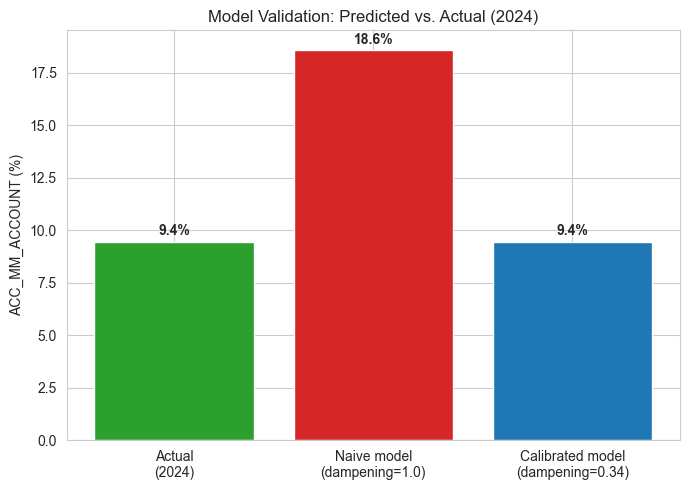

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
labels = ["Actual\n(2024)", "Naive model\n(dampening=1.0)", f"Calibrated model\n(dampening={calibrated_dampening:.2f})"]
values = [actual_t1, result_naive["predicted_t1"], result_calibrated["predicted_t1"]]
colors = ["#2ca02c", "#d62728", "#1f77b4"]
bars = ax.bar(labels, values, color=colors)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, f"{v:.1f}%", ha="center", fontweight="bold")
ax.set_ylabel("ACC_MM_ACCOUNT (%)")
ax.set_title("Model Validation: Predicted vs. Actual (2024)")
plt.tight_layout()
plt.savefig(FIG_DIR / "validation_naive_vs_calibrated.png", dpi=150)
plt.show()


## 6. Refine Estimates

Applying the calibrated dampening factor (solved above) specifically to comparable-country
(`literature`/`theoretical`) evidence-based effects — Ethiopia-specific `empirical` effects
keep full weight, since they aren't the thing the validation exercise cast doubt on.


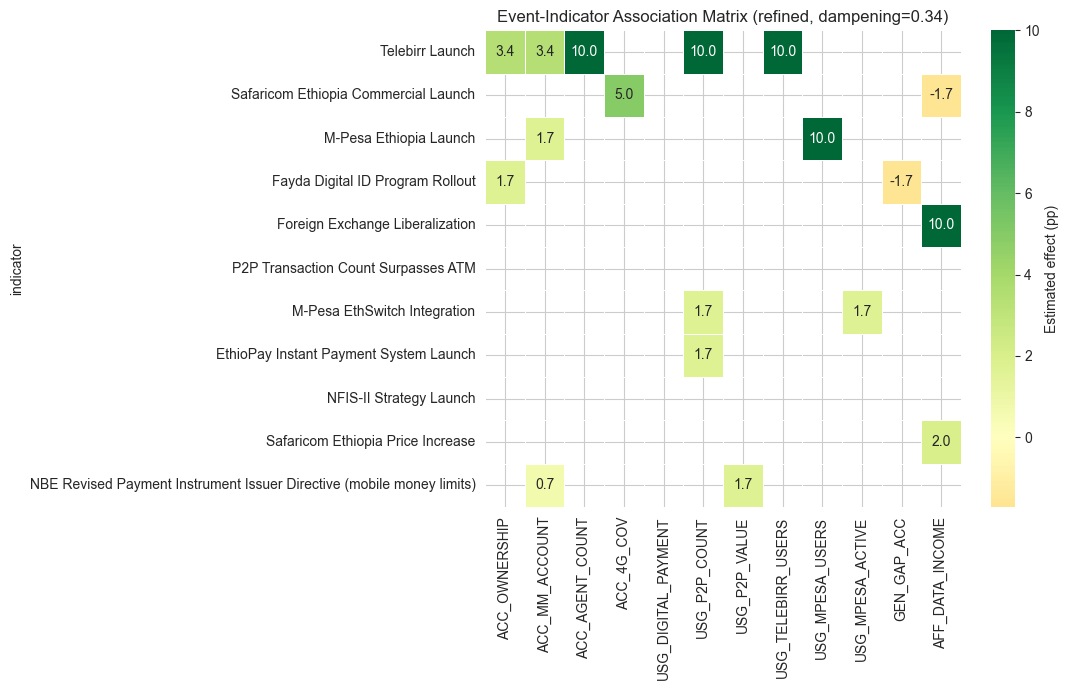

In [13]:
refined_matrix = build_association_matrix(df, key_indicators, dampening=calibrated_dampening)
refined_matrix.to_csv(PROCESSED_DIR / "event_indicator_association_matrix_refined.csv")

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(refined_matrix.astype(float), cmap="RdYlGn", center=0, annot=True, fmt=".1f",
            linewidths=0.5, linecolor="white", cbar_kws={"label": "Estimated effect (pp)"}, ax=ax)
ax.set_title(f"Event-Indicator Association Matrix (refined, dampening={calibrated_dampening:.2f})")
plt.tight_layout()
plt.savefig(FIG_DIR / "association_matrix_refined.png", dpi=150)
plt.show()


**What changed, and what didn't:**
- All `literature`/`theoretical` estimates (Kenya, India, Rwanda, Tanzania comparable-country
  evidence) shrank by the calibrated factor — they were the source of the overshoot.
- `empirical` Ethiopia-specific estimates (e.g. Telebirr → `USG_TELEBIRR_USERS`,
  Telebirr → `USG_P2P_COUNT`) are **unchanged** — the validation case gave no evidence they're
  wrong, so scaling them down would be an unjustified assumption stacked on top of an already
  uncertain one.

**Confidence going into Task 4**:
- **High confidence**: the 4 `empirical`, Ethiopia-specific links (all involving Telebirr's
  direct, measured effects).
- **Medium confidence**: the calibrated comparable-country links — better than the naive
  version, but calibrated from a **single validation case**. One data point cannot fully
  validate a dampening factor; treat it as a reasonable starting assumption, not a proven
  constant.
- **Low confidence**: the brand-new Telebirr → `ACC_MM_ACCOUNT` link added in Section 3, and
  the NBE directive → `ACC_MM_ACCOUNT` link (`IMP_0017`, already low-confidence from Task 1) —
  both rely on the least Ethiopia-specific evidence in the dataset.


In [14]:
# Save the calibration result for Task 4 to reuse
calibration_summary = pd.DataFrame([{
    "calibrated_dampening": calibrated_dampening,
    "validation_indicator": "ACC_MM_ACCOUNT",
    "validation_window": f"{t0.date()} to {t1.date()}",
    "naive_predicted_t1": result_naive["predicted_t1"],
    "calibrated_predicted_t1": result_calibrated["predicted_t1"],
    "actual_t1": actual_t1,
}])
calibration_summary.to_csv(PROCESSED_DIR / "impact_model_calibration.csv", index=False)
calibration_summary


,calibrated_dampening,validation_indicator,validation_window,naive_predicted_t1,calibrated_predicted_t1,actual_t1
0,0.341931,ACC_MM_ACCOUNT,2021-12-31 to 2024-11-29,18.5917,9.45,9.45


## 7. Methodology, Assumptions, and Limitations

**Functional form.** Each event's effect on an indicator is modeled as a linear ramp: 0 at
the event date, rising to its full estimated magnitude at `event_date + lag_months`, then
holding flat indefinitely (no decay). Multiple events affecting the same indicator combine
additively. Both choices are simplifications chosen because the underlying data (per Task 2)
is too sparse to fit anything more sophisticated — a defensible starting point, not a claim
that adoption curves are actually linear or that effects never interact.

**Magnitude quantification.** Categorical `low/medium/high` magnitudes are mapped to
2/5/10 percentage points respectively — an explicit, arbitrary-but-documented starting
assumption. This is the single biggest source of uncertainty in the whole model, since it
applies uniformly regardless of which indicator or event is involved.

**Comparable-country dampening.** Effects sourced from `literature`/`theoretical` evidence
(i.e. comparable-country precedent, not Ethiopia's own data) are down-weighted by a factor
calibrated against one validation case (Telebirr → `ACC_MM_ACCOUNT`, 2021-2024). This factor
(~0.34, i.e. comparable-country effects are scaled to about a third of their naive size) should
be treated as provisional — it is back-solved from a single data point and will need
re-validation once more Ethiopia data becomes available (e.g. after the next Findex round).

**Key assumptions:**
1. Effects are additive across events (no saturation, no interaction, no diminishing returns
   as multiple products compete for the same pool of potential adopters).
2. An indicator's `t0` baseline value already embeds whatever effect was realized before
   `t0` — the model only predicts the *incremental* change from `t0` onward, using
   `ramp(t1) - ramp(t0)`, to avoid double-counting.
3. `lag_months` values from the dataset are treated as fixed, known quantities, even though
   several are themselves comparable-country-derived estimates with their own uncertainty.

**Limitations:**
- Only one real validation case was possible (`ACC_MM_ACCOUNT`) — Findex's 3-year survey
  cadence (flagged repeatedly since Task 2) means most other indicators don't have a clean
  "before event, after event" pair with only that event in between.
- The calibrated dampening factor is Ethiopia-market-wide, not event- or indicator-specific
  — a real refinement would fit separate factors per indicator once more data exists.
- The association matrix (Section 4/6) presents point estimates with no uncertainty
  interval — Task 4 will need to carry this uncertainty forward explicitly (e.g. as scenario
  bands), not treat these numbers as precise.
